In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
df = pd.read_csv(r"C:\Users\hi\OneDrive\Documents\Working\dataset\Mall_Customers.csv")

In [4]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [6]:
df.shape

(200, 5)

In [7]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [8]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.drop("CustomerID", axis=1, inplace=True)

In [11]:
import matplotlib.pyplot as plt

In [12]:
import seaborn as sns

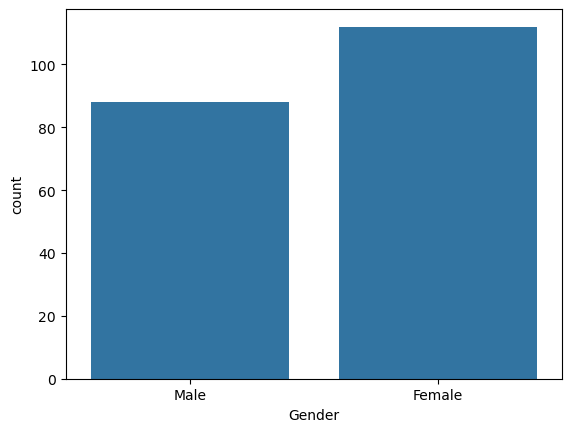

In [13]:
sns.countplot(x='Gender', data=df)
plt.show()

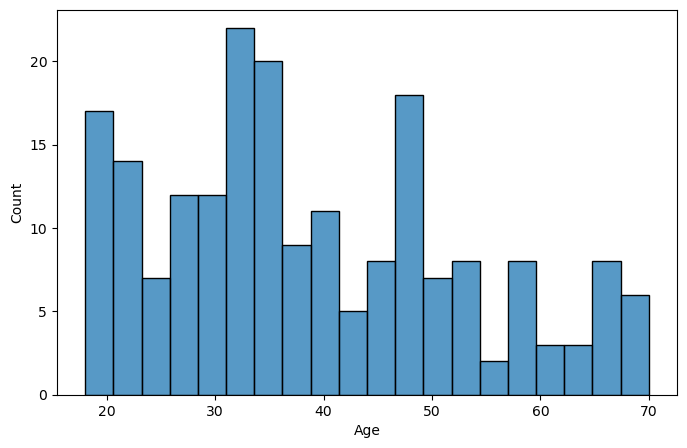

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20)
plt.show()

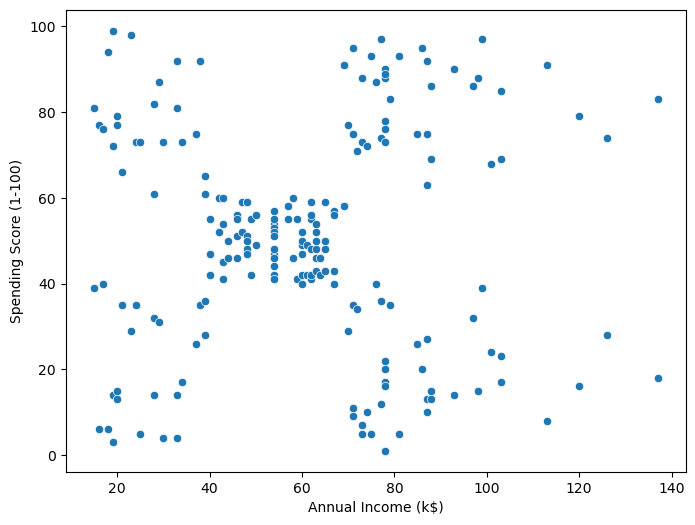

In [15]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    data=df
)
plt.show()

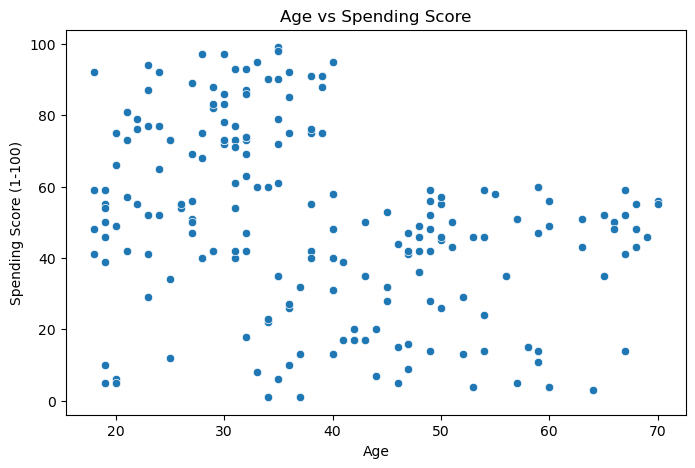

In [31]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='Age',
    y='Spending Score (1-100)',
    data=df
)
plt.title("Age vs Spending Score")
plt.show()

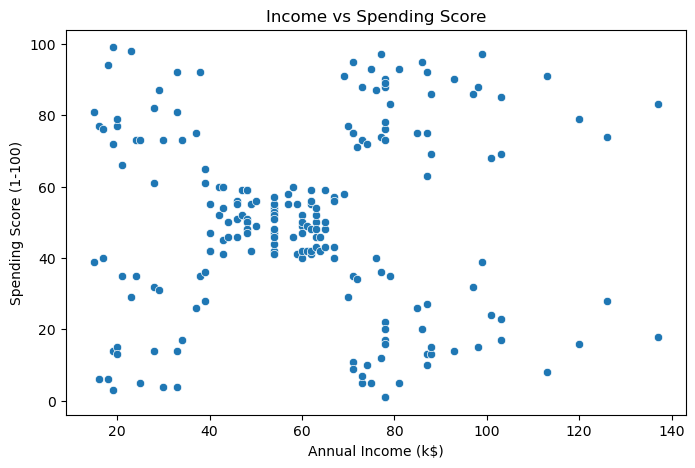

In [32]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    data=df
)
plt.title("Income vs Spending Score")
plt.show()

In [33]:
df.groupby('Gender')['Spending Score (1-100)'].mean()

Gender
Female    51.526786
Male      48.511364
Name: Spending Score (1-100), dtype: float64

In [34]:
df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[0,25,40,60,100],
    labels=['Young','Adult','Middle Age','Senior']
)

In [35]:
df.groupby('Age_Group')['Spending Score (1-100)'].mean()

C:\Users\hi\AppData\Local\Temp\ipykernel_12232\2472981043.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Age_Group')['Spending Score (1-100)'].mean()


Age_Group
Young         54.947368
Adult         61.261905
Middle Age    33.688525
Senior        44.176471
Name: Spending Score (1-100), dtype: float64

C:\Users\hi\AppData\Local\Temp\ipykernel_12232\978186283.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Age_Group')['Spending Score (1-100)'].mean().plot(kind='bar')


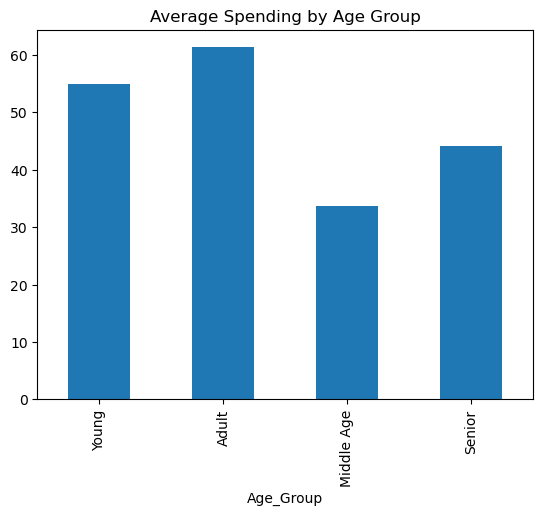

In [36]:
df.groupby('Age_Group')['Spending Score (1-100)'].mean().plot(kind='bar')
plt.title("Average Spending by Age Group")
plt.show()

In [17]:
X = df[['Annual Income (k$)','Spending Score (1-100)']]

In [19]:
from sklearn.preprocessing import StandardScaler

In [20]:
scaler = StandardScaler()

In [21]:
X_scaled = scaler.fit_transform(X)

In [22]:
from sklearn.cluster import KMeans

In [23]:
wcss = []
for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

C:\Users\hi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\hi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\hi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\hi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, 

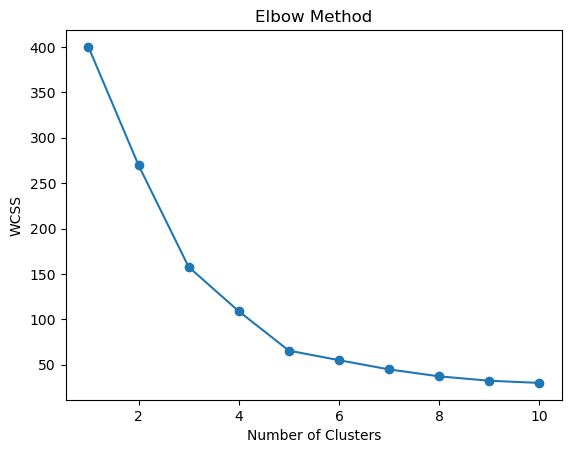

In [24]:
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

In [25]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

In [26]:
df['Cluster'] = kmeans.fit_predict(X_scaled)

C:\Users\hi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


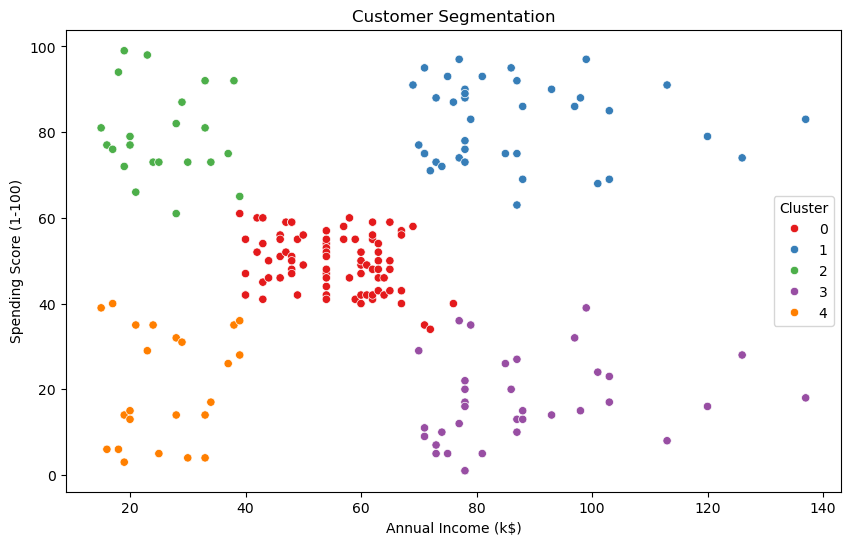

In [27]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set1',
    data=df
)
plt.title('Customer Segmentation')
plt.show()

In [28]:
profile = df.groupby('Cluster').mean(numeric_only=True)

In [29]:
profile

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043


In [30]:
df['Cluster'].value_counts()

Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64